In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import math
import lightgbm as lgb
import seaborn as sns
import joblib as jbl
from catboost import CatBoostClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df = pd.read_parquet("US_accidents_dataset.parquet")
df.drop(columns=["Turning_Loop", "End_Lat", "End_Lng", "Airport_Code"], inplace=True)

df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
df['End_Time']   = pd.to_datetime(df['End_Time'],   format='mixed')
df['duration_min'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
df['hour']  = df['Start_Time'].dt.hour
df['month'] = df['Start_Time'].dt.month

def is_us_holiday(dt):
    m, d = dt.month, dt.day
    if (m == 12 and d >= 24) or (m == 1 and d <= 2): return 1
    if m == 11 and d >= 22:      return 1
    if m == 7  and d == 4:       return 1
    if m == 5  and d >= 25:      return 1
    if m == 9  and d <= 7:       return 1
    if m == 10 and d == 31:      return 1
    if m == 2  and 7 <= d <= 10: return 1
    return 0

df['is_holiday_period'] = df['Start_Time'].apply(is_us_holiday)
df.drop(columns=['Start_Time', 'End_Time', 'Weather_Timestamp'], inplace=True)
df.drop(columns=['Wind_Chill(F)', 'Country'], inplace=True)

def time_of_day(h):
    if 6  <= h < 9:  return 0  # morning_rush
    if 9  <= h < 16: return 1  # daytime
    if 16 <= h < 19: return 2  # evening_rush
    if 19 <= h < 23: return 3  # evening
    return 4                   # night

df['time_of_day'] = df['hour'].apply(time_of_day)

# Encoding ciclico mese
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df.drop(columns=['hour', 'month'], inplace=True)

def group_weather(w):
    if pd.isna(w): return 'Unknown'
    w = str(w).lower()
    if any(x in w for x in ['thunder', 't-storm', 'thunderstorm', 'tornado', 'funnel']): return 'Storm'
    if any(x in w for x in ['snow', 'blizzard', 'wintry', 'sleet', 'ice pellet', 'snow grain', 'freezing', 'hail']): return 'Snow_Ice'
    if any(x in w for x in ['heavy rain', 'rain shower', 'rain', 'drizzle', 'shower']): return 'Rain'
    if any(x in w for x in ['fog', 'mist', 'haze']):                                    return 'Fog_Low_Visibility'
    if any(x in w for x in ['smoke', 'dust', 'sand', 'ash', 'squall']):                 return 'Dust_Smoke'
    if any(x in w for x in ['cloud', 'overcast', 'scattered', 'mostly', 'partly']):     return 'Cloudy'
    if any(x in w for x in ['clear', 'fair', 'sunny']):                                 return 'Clear'
    return 'Other'

def weather_intensity(w):
    if pd.isna(w): return np.nan
    w = str(w).lower()
    if any(x in w for x in ['heavy', 'severe', 'tornado', 'funnel', 'blizzard', 'duststorm']): return 3
    if any(x in w for x in ['moderate', 'thunder', 't-storm', 'squall', 'wintry mix']):         return 2
    if any(x in w for x in ['light', 'drizzle', 'mist', 'shallow', 'partial', 'patches']):      return 1
    return 0

df['Weather_Group']     = df['Weather_Condition'].apply(group_weather)
df['Weather_Intensity'] = df['Weather_Condition'].apply(weather_intensity)
df.drop(columns=['Weather_Condition'], inplace=True)

def classify_street(name):
    if pd.isna(name): return 'Unknown'
    name_upper = str(name).upper().strip()
    name_clean = re.sub(r'\s+(N|S|E|W|NE|NW|SE|SW)$', '', name_upper).strip()
    if re.match(r'^I-\d+', name_clean):          return 'Interstate'
    if re.match(r'^US-\d+', name_clean):         return 'US_Route'
    if re.match(r'^[A-Z]{2}-\d+', name_clean):  return 'State_Route'
    if any(x in name_clean for x in ['FWY', 'FREEWAY', 'EXPRESSWAY', 'EXPY', 'TPKE', 'TURNPIKE', 'PIKE']): return 'Freeway_Expressway'
    if any(x in name_clean for x in ['HWY', 'HIGHWAY']):    return 'Highway'
    if any(x in name_clean for x in ['PKWY', 'PARKWAY']):   return 'Parkway'
    if any(x in name_clean for x in ['BLVD', 'BOULEVARD']): return 'Boulevard'
    if any(x in name_clean for x in [' AVE', 'AVENUE']):    return 'Avenue'
    if any(x in name_clean for x in [' RD', ' ROAD']):      return 'Road'
    if any(x in name_clean for x in [' ST', ' STREET']):    return 'Street'
    if any(x in name_clean for x in [' DR', ' DRIVE']):     return 'Drive'
    if any(x in name_clean for x in [' LN', ' LANE']):      return 'Lane'
    if any(x in name_clean for x in [' TRL', ' TRAIL']):    return 'Trail'
    if any(x in name_clean for x in [' CT', ' COURT', ' CIR', ' CIRCLE', ' PL', ' PLACE', ' WAY']): return 'Local'
    return 'Other'

df['Street_Type'] = df['Street'].apply(classify_street)
df.drop(columns=['Street'], inplace=True)

df.drop(columns=['ID'], inplace=True)
df['desc_length']         = df['Description'].str.len()
df['lanes_blocked']       = df['Description'].str.extract(r'(\d+)\s+lane', expand=False).fillna(0).astype(int)
df['mentions_closed']     = df['Description'].str.contains(r'closed|closure',         case=False, na=False).astype(int)
df['mentions_blocked']    = df['Description'].str.contains(r'blocked',                case=False, na=False).astype(int)
df['mentions_stationary'] = df['Description'].str.contains(r'stationary traffic',     case=False, na=False).astype(int)
df['mentions_slow']       = df['Description'].str.contains(r'slow traffic',           case=False, na=False).astype(int)
df['mentions_delay']      = df['Description'].str.contains(r'delay|expect delay',     case=False, na=False).astype(int)
df['mentions_shoulder']   = df['Description'].str.contains(r'shoulder',               case=False, na=False).astype(int)
df['unconfirmed']         = df['Description'].str.contains(r'unconfirmed',            case=False, na=False).astype(int)
df['multiple_vehicles']   = df['Description'].str.contains(r'\d+\s*veh|multiple veh', case=False, na=False).astype(int)
df['desc_highway']        = df['Description'].str.contains(r'I-\d+|interstate|freeway|fwy|pkwy|expy', case=False, na=False).astype(int)
df['drive_caution']       = df['Description'].str.contains(r'drive with caution|use caution', case=False, na=False).astype(int)
df['crash_confirmed']     = df['Description'].str.contains(r'crash|accident',         case=False, na=False).astype(int)
df.drop(columns=['Description'], inplace=True)

bool_cols = ['Amenity','Bump','Crossing','Give_Way','Junction',
             'No_Exit','Railway','Roundabout','Station','Stop',
             'Traffic_Calming','Traffic_Signal']
df[bool_cols] = df[bool_cols].astype(int)

df['Sunrise_Sunset'] = (df['Sunrise_Sunset'] == 'Day').astype(int)
df.drop(columns=['Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight'], inplace=True)

direction_map = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5,
    'Calm': -1, 'VAR': -1, 'Variable': -1
}
df['Wind_Deg']  = df['Wind_Direction'].map(direction_map)
df['Wind_Sin']  = np.where(df['Wind_Deg'] >= 0, np.sin(np.radians(df['Wind_Deg'])), 0)
df['Wind_Cos']  = np.where(df['Wind_Deg'] >= 0, np.cos(np.radians(df['Wind_Deg'])), 0)
df['Wind_Calm'] = (df['Wind_Deg'] < 0).astype(int)
df.drop(columns=['Wind_Direction', 'Wind_Deg'], inplace=True)

source_map = {'Source1': 0, 'Source2': 1, 'Source3': 2}
df['Source'] = df['Source'].map(source_map)

df.drop(columns=[
    'Roundabout', 'Bump', 'Traffic_Calming', 'No_Exit',
    'unconfirmed', 'Amenity', 'Railway', 'Give_Way',
    'multiple_vehicles', 'Station', 'Weather_Windy', 'Timezone'
], inplace=True, errors='ignore')

num_cols = df.select_dtypes(include=['float64', 'float32', 'int64']).columns
num_cols = [c for c in num_cols if c != 'Severity']

for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

cols_to_log = ['duration_min', 'Distance(mi)', 'Wind_Speed(mph)', 'desc_length']
for col in cols_to_log:
    df[f'{col}_log'] = np.log1p(df[col].clip(lower=0))
    df.drop(columns=[col], inplace=True)

df['Distance(mi)_log'] = np.log1p(df['Distance(mi)_log'])

if 'Precipitation(in)' in df.columns:
    df['is_raining'] = (df['Precipitation(in)'] > 0).astype(int)
    df.drop(columns=['Precipitation(in)'], inplace=True)

# Alta cardinalità → frequency encoding PRIMA di one-hot
for col in ['City', 'County', 'Zipcode', 'State']:
    freq = df[col].value_counts()
    df[col] = df[col].map(freq)

# Categoriche → one hot
cat_cols = ['Weather_Group', 'Street_Type']
df = pd.get_dummies(df, columns=cat_cols, dtype=int)

# Riempi i NaN rimasti (frequency encoding, Weather_Intensity, ecc.)
# Per colonne numeriche: usa mediana; per le altre: usa 0
for col in df.columns:
    if col != 'Severity' and df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'float32', 'int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(0)

print(f"Shape dopo preprocessing: {df.shape}")
print(f"NaN rimasti: {df.isnull().sum().sum()}")

Shape dopo preprocessing: (7728394, 65)
NaN rimasti: 0


In [3]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.version.cuda)

True
NVIDIA GeForce RTX 4060 Laptop GPU
12.4


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando: {device}")

# Split sul DATAFRAME (non array) per preservare le colonne
X_indices = np.arange(len(df))
y = (df['Severity'] - 1).values.astype('int64')

X_temp_idx, X_test_idx, y_temp, y_test = train_test_split(
    X_indices, y, test_size=0.2, random_state=42, stratify=y)

X_train_idx, X_val_idx, y_train, y_val = train_test_split(
    X_temp_idx, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

# Ottieni i dataframe
X_train_df = df.iloc[X_train_idx].drop(columns=['Severity'])
X_val_df   = df.iloc[X_val_idx].drop(columns=['Severity'])
X_test_df  = df.iloc[X_test_idx].drop(columns=['Severity'])

print(f"Train: {X_train_df.shape}")
print(f"Val:   {X_val_df.shape}")
print(f"Test:  {X_test_df.shape}")

# KMeans SOLO sul training set (per evitare data leakage)
km = KMeans(n_clusters=10, random_state=42, n_init=10)
km.fit(X_train_df[['Start_Lat', 'Start_Lng']].sample(min(200000, len(X_train_df)), random_state=42))

# Predici i cluster per tutti i set
X_train_df['Geo_Cluster'] = km.predict(X_train_df[['Start_Lat', 'Start_Lng']])
X_val_df['Geo_Cluster']   = km.predict(X_val_df[['Start_Lat', 'Start_Lng']])
X_test_df['Geo_Cluster']  = km.predict(X_test_df[['Start_Lat', 'Start_Lng']])

# Ora converti in array numpy
X_train = X_train_df.values.astype('float32')
X_val   = X_val_df.values.astype('float32')
X_test  = X_test_df.values.astype('float32')

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


# Converti in tensori e sposta su device
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_val_t   = torch.FloatTensor(X_val).to(device)
y_val_t   = torch.LongTensor(y_val).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.LongTensor(y_test).to(device)

# DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=4096, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=4096, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=4096, shuffle=False)

Usando: cuda
Train: (4946172, 64)
Val:   (1236543, 64)
Test:  (1545679, 64)


In [5]:
lgb_test_probs = jbl.load('lgb_test_probs.pkl')
lgb_val_probs  = jbl.load('lgb_val_probs.pkl')

# Carica le probabilità del Residual MLP
nn_val_probs  = jbl.load('nn_val_probs_2.pkl')
nn_test_probs = jbl.load('nn_test_probs_2.pkl')

print(f"lgb_val_probs shape:  {lgb_val_probs.shape}")
print(f"lgb_test_probs shape: {lgb_test_probs.shape}")
print(f"nn_val_probs shape:   {nn_val_probs.shape}")
print(f"nn_test_probs shape:  {nn_test_probs.shape}")

lgb_val_probs shape:  (1236543, 4)
lgb_test_probs shape: (1545679, 4)
nn_val_probs shape:   (1236543, 4)
nn_test_probs shape:  (1545679, 4)


In [6]:
from sklearn.metrics import f1_score

# Ottimizza pesi tra LGB e NN sul val set
best_f1 = 0
best_w_lgb = 0

print("Ricerca combinazione ottimale di pesi (LGB + NN)...\n")

for w_lgb in np.arange(0.1, 1.0, 0.1):
    w_nn = 1.0 - w_lgb
    
    ensemble_probs = w_lgb * lgb_val_probs + w_nn * nn_val_probs
    ensemble_preds = ensemble_probs.argmax(axis=1)
    f1 = f1_score(y_val, ensemble_preds, average='macro')
    
    print(f"LGB={w_lgb:.1f} NN={w_nn:.1f} → Val F1: {f1:.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_w_lgb = w_lgb

best_w_nn = 1.0 - best_w_lgb
print(f"\nMiglior combinazione: LGB={best_w_lgb:.1f} NN={best_w_nn:.1f}")
print(f"Val F1: {best_f1:.4f}")

# Predizioni finali sul test
ensemble_probs_best = best_w_lgb * lgb_test_probs + best_w_nn * nn_test_probs
ensemble_preds_best = ensemble_probs_best.argmax(axis=1)

Ricerca combinazione ottimale di pesi (LGB + NN)...

LGB=0.1 NN=0.9 → Val F1: 0.6560
LGB=0.2 NN=0.8 → Val F1: 0.6675
LGB=0.3 NN=0.7 → Val F1: 0.6836
LGB=0.4 NN=0.6 → Val F1: 0.7090
LGB=0.5 NN=0.5 → Val F1: 0.7559
LGB=0.6 NN=0.4 → Val F1: 0.7866
LGB=0.7 NN=0.3 → Val F1: 0.7985
LGB=0.8 NN=0.2 → Val F1: 0.8027
LGB=0.9 NN=0.1 → Val F1: 0.8035

Miglior combinazione: LGB=0.9 NN=0.1
Val F1: 0.8035


In [7]:
ensemble_probs_best = best_w_lgb * lgb_test_probs + (1 - best_w_lgb) * nn_test_probs
ensemble_preds_best = ensemble_probs_best.argmax(axis=1)

print("\n" + "="*60)
print("CLASSIFICATION REPORT - ENSEMBLE FINALE")
print("="*60)
print(classification_report(y_test, ensemble_preds_best,
      target_names=['Severity 1','Severity 2','Severity 3','Severity 4']))


CLASSIFICATION REPORT - ENSEMBLE FINALE
              precision    recall  f1-score   support

  Severity 1       0.72      0.65      0.68     13473
  Severity 2       0.97      0.95      0.96   1231396
  Severity 3       0.84      0.91      0.87    259868
  Severity 4       0.64      0.78      0.70     40942

    accuracy                           0.93   1545679
   macro avg       0.79      0.82      0.80   1545679
weighted avg       0.94      0.93      0.94   1545679



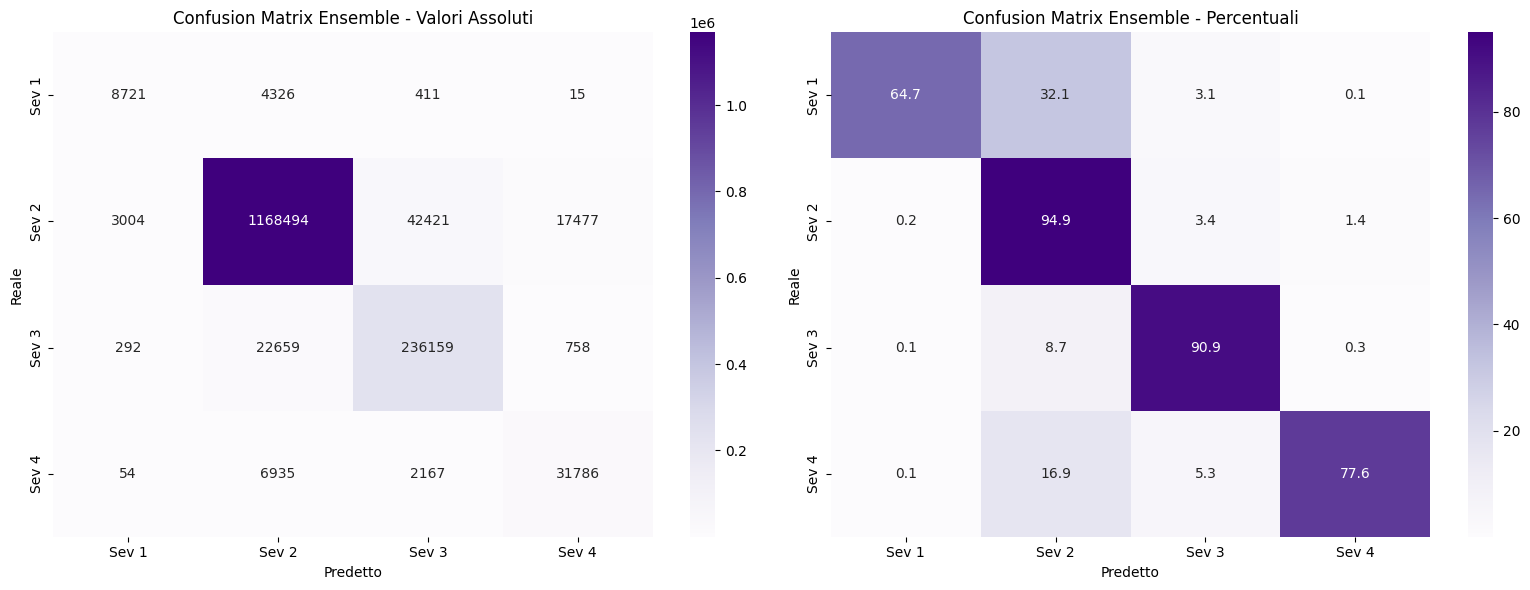

In [ ]:
cm         = confusion_matrix(y_test, ensemble_preds_best)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix Ensemble - Valori Assoluti')
axes[0].set_ylabel('Reale')
axes[0].set_xlabel('Predetto')

sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Purples',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix Ensemble - Percentuali')
axes[1].set_ylabel('Reale')
axes[1].set_xlabel('Predetto')

plt.tight_layout()
plt.show()